# Tamang ASL

In [ ]:
# System, Core File Management, and Extraction
import os
import re
import shutil
import zipfile
import random

!pip install split-folders
!pip install mediapipe
# External Package Managers & Progress Trackers
import splitfolders

# Data Analysis, Linear Algebra, and Plotting
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Image Processing and Computer Vision
import cv2
import mediapipe as mp
from mediapipe.tasks import python
from mediapipe.tasks.python import vision

# Deep Learning Framework (TensorFlow & Keras)
import tensorflow as tf
from keras.models import Sequential, load_model
from keras.layers import (Dense, Conv2D, Dropout, Flatten, MaxPooling2D,
                           BatchNormalization, Input, Rescaling,
                           RandomFlip, RandomRotation, RandomZoom)
from keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from keras.utils import plot_model

# Statistical Evaluation & Verification Metrics
from sklearn.metrics import classification_report, confusion_matrix


In [ ]:
# Initialize Kaggle credentials
import os
import json

KAGGLE_USERNAME = "russelllawrencesison"
KAGGLE_KEY = "KGAT_c24f6cc439dd8fb1d19cd8ba29cfa599"

credentials = {
    "username": KAGGLE_USERNAME,
    "key": KAGGLE_KEY
}

os.makedirs(os.path.expanduser("~/.kaggle"), exist_ok=True)
json_path = os.path.expanduser("~/.kaggle/kaggle.json")

with open(json_path, "w") as f:
    json.dump(credentials, f)

os.chmod(json_path, 0o600)

print("Kaggle API credentials generated successfully! Ready to download your datasets.")

Kaggle API credentials generated successfully! Ready to download your datasets.


In [ ]:
# Install Kaggle Datasets to Colab
!pip install -q kaggle
!pip install -q split-folders

if not os.path.exists('/root/.kaggle/kaggle.json'):
    print("Please upload your downloaded 'kaggle.json' token file:")
    uploaded = files.upload()

    !mkdir -p ~/.kaggle
    !mv kaggle.json ~/.kaggle/
    !chmod 600 ~/.kaggle/kaggle.json
    print("Kaggle API successfully authenticated!")

datasets = {
    "asl_alphabet": "grassknoted/asl-alphabet",                   # Dataset 1: 87,000 images
    "sl_mnist": "datamunge/sign-language-mnist",                  # Dataset 2: 34,627 images
    "asl_varied": "ayuraj/asl-dataset"                            # Dataset 3: 2,515 images
}

os.makedirs("raw_data/asl_alphabet", exist_ok=True)
os.makedirs("raw_data/sl_mnist", exist_ok=True)
os.makedirs("raw_data/asl_varied", exist_ok=True)

print("\n--- Starting High-Speed Cloud Downloads ---")

# Download Datasets
print("Downloading ASL Alphabet Dataset...")
!kaggle datasets download -d {datasets['asl_alphabet']} -p raw_data/asl_alphabet

print("Downloading Sign Language MNIST...")
!kaggle datasets download -d {datasets['sl_mnist']} -p raw_data/sl_mnist

print("Downloading Varied ASL Dataset...")
!kaggle datasets download -d {datasets['asl_varied']} -p raw_data/asl_varied

# Fast Cloud Extraction Routine
print("\n--- Extracting Zip Archives ---")
for folder in os.listdir("raw_data"):
    folder_path = os.path.join("raw_data", folder)
    for file in os.listdir(folder_path):
        if file.endswith(".zip"):
            zip_file_path = os.path.join(folder_path, file)
            print(f"Extracting {file}...")
            with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
                zip_ref.extractall(folder_path)
            os.remove(zip_file_path)

print("\nAll datasets integrated and extracted locally inside Colab!")


--- Starting High-Speed Cloud Downloads ---
Dataset URL: https://www.kaggle.com/datasets/grassknoted/asl-alphabet
License(s): GPL-2.0
100% 1.03G/1.03G [00:06<00:00, 170MB/s]

Dataset URL: https://www.kaggle.com/datasets/datamunge/sign-language-mnist
License(s): CC0-1.0
100% 62.6M/62.6M [00:00<00:00, 139MB/s]

Dataset URL: https://www.kaggle.com/datasets/ayuraj/asl-dataset
License(s): CC0-1.0
100% 56.9M/56.9M [00:00<00:00, 82.9MB/s]


--- Extracting Zip Archives ---
Extracting sign-language-mnist.zip...
Extracting asl-alphabet.zip...
Extracting asl-dataset.zip...

All datasets integrated and extracted locally inside Colab!


In [ ]:
# DATA PREPROCESSING

import os
import cv2
import shutil
import numpy as np
import pandas as pd

# Standardizeand combine all 3 datasets into one master dataset
UNIFIED_DIR = "master_asl_dataset"

if os.path.exists(UNIFIED_DIR):
    shutil.rmtree(UNIFIED_DIR)

# Create folders for lowercase letters a to z (26 classes)
for char in "abcdefghijklmnopqrstuvwxyz":
    os.makedirs(os.path.join(UNIFIED_DIR, char), exist_ok=True)

print("Standardizing and merging alphabet-only images into 'master_asl_dataset'...")

# Process Dataset 1 'ASL Dataset' (Varied 400x400 RGB)
src_varied = "raw_data/asl_varied/asl_dataset/asl_dataset"
if os.path.exists(src_varied):
    for class_folder in os.listdir(src_varied):
        # Exclude numerical classes (0-9)
        if class_folder.lower() in "abcdefghijklmnopqrstuvwxyz" and len(class_folder) == 1:
            class_path = os.path.join(src_varied, class_folder)
            if os.path.isdir(class_path):
                target_folder = os.path.join(UNIFIED_DIR, class_folder.lower())
                for img_file in os.listdir(class_path):
                    src_file = os.path.join(class_path, img_file)
                    if os.path.isfile(src_file):
                        shutil.copy(src_file, os.path.join(target_folder, f"varied_{img_file}"))

# Process Dataset 2 'ASL Alphabet' (200x200 RGB)
src_alphabet = "raw_data/asl_alphabet/asl_alphabet_train/asl_alphabet_train"
if os.path.exists(src_alphabet):
    for class_folder in os.listdir(src_alphabet):
        # STRIP NUMBERS: Only process single-character alphabetic folders
        if class_folder.lower() in "abcdefghijklmnopqrstuvwxyz" and len(class_folder) == 1:
            class_path = os.path.join(src_alphabet, class_folder)
            target_folder = os.path.join(UNIFIED_DIR, class_folder.lower())
            os.makedirs(target_folder, exist_ok=True)
            for img_file in os.listdir(class_path):
                src_file = os.path.join(class_path, img_file)
                if os.path.isfile(src_file):
                    shutil.copy(src_file, os.path.join(target_folder, f"alph_{img_file}"))

# --- Process Dataset 3 'Sign Language MNIST'  ---
# NOTE: This dataset skips 'J' (9) and 'Z' (25). Needs proper class handling
labels_used = [i for i in range(26) if i not in (9, 25)]
mnist_mapping = {label: chr(ord('a') + idx) for idx, label in enumerate(labels_used)}
print(f"MNIST label mapping (corrected): {mnist_mapping}")

# CSV Rows to RGB Images
def process_mnist_csv(csv_path):
    if os.path.exists(csv_path):
        df_mnist = pd.read_csv(csv_path)
        labels = df_mnist['label'].values
        pixels = df_mnist.drop(columns=['label']).values

        for idx, (label, pixel_row) in enumerate(zip(labels, pixels)):
            letter = mnist_mapping.get(label, None)
            # The check ensures it maps strictly to our remaining 'a'-'z' system folders
            if letter and letter in "abcdefghijklmnopqrstuvwxyz":
                img_matrix = pixel_row.reshape(28, 28).astype(np.uint8)
                img_resized = cv2.resize(img_matrix, (200, 200))    # Upscale into 200x200 from 28x28
                img_rgb = cv2.cvtColor(img_resized, cv2.COLOR_GRAY2RGB)

                target_path = os.path.join(UNIFIED_DIR, letter, f"mnist_{idx}.jpg")
                cv2.imwrite(target_path, img_rgb)

process_mnist_csv("raw_data/sl_mnist/sign_mnist_train.csv")
process_mnist_csv("raw_data/sl_mnist/sign_mnist_test.csv")

# Cleanup Empty Directories
for folder in os.listdir(UNIFIED_DIR):
    folder_path = os.path.join(UNIFIED_DIR, folder)
    if os.path.isdir(folder_path) and len(os.listdir(folder_path)) == 0:
        os.rmdir(folder_path)

print("\nData pipeline consolidation complete! Total images compiled across unified targets:")
for folder in sorted(os.listdir(UNIFIED_DIR)):
    print(f"Class '{folder}': {len(os.listdir(os.path.join(UNIFIED_DIR, folder)))} images")


Standardizing and merging alphabet-only images into 'master_asl_dataset'...
MNIST label mapping (corrected): {0: 'a', 1: 'b', 2: 'c', 3: 'd', 4: 'e', 5: 'f', 6: 'g', 7: 'h', 8: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x'}

Data pipeline consolidation complete! Total images compiled across unified targets:
Class 'a': 4515 images
Class 'b': 4491 images
Class 'c': 4512 images
Class 'd': 4498 images
Class 'e': 4502 images
Class 'f': 4510 images
Class 'g': 4493 images
Class 'h': 4509 images
Class 'i': 4505 images
Class 'j': 4504 images
Class 'k': 4509 images
Class 'l': 4509 images
Class 'm': 4499 images
Class 'n': 4505 images
Class 'o': 4496 images
Class 'p': 4504 images
Class 'q': 4500 images
Class 'r': 4503 images
Class 's': 4494 images
Class 't': 4476 images
Class 'u': 4480 images
Class 'v': 4490 images
Class 'w': 4493 images
Class 'x': 4507 images
Class 'y': 3070 images
Class 'z': 3070 images


In [ ]:
# DATASET SPLIT: 80/10/10 Train-Val-Test Split

if os.path.exists('split_dataset'):
    shutil.rmtree('split_dataset')

# Split balanced master folder into structured training, validation, and test folders
splitfolders.ratio('master_asl_dataset', output='split_dataset', seed=1333, ratio=(0.8, 0.1, 0.1))
print("Dataset successfully divided into 'split_dataset/'!")

Copying files: 114144 files [00:38, 2989.04 files/s]

Dataset successfully divided into 'split_dataset/'!


Dynamic Security Guard: 26 target classes detected on disk.
Class Mapping Configured: ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z']
Found 91308 files belonging to 26 classes.
Found 11404 files belonging to 26 classes.
Found 11432 files belonging to 26 classes.


/tmp/ipykernel_3300/4086049180.py:77: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(input_shape=(200, 200, 3), include_top=False, weights='imagenet')


Model: "TamangASL_MobileNet"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 200, 200, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 26)             │         3,354 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,425,306 (9.25 MB)

 Trainable params: 167,322 (653.60 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Epoch 1/30
1427/1427 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 0.6961 - loss: 1.0661
Epoch 1: val_accuracy improved from None to 0.97764, saving model to best_TamangASL.keras

Epoch 1: finished saving model to best_TamangASL.keras
1427/1427 ━━━━━━━━━━━━━━━━━━━━ 132s 78ms/step - accuracy: 0.8438 - loss: 0.5388 - val_accuracy: 0.9776 - val_loss: 0.0931 - learning_rate: 0.0010
Epoch 2/30
1426/1427 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.9500 - loss: 0.1633
Epoch 2: val_accuracy improved from 0.97764 to 0.98360, saving model to best_TamangASL.keras

Epoch 2: finished saving model to best_TamangASL.keras
1427/1427 ━━━━━━━━━━━━━━━━━━━━ 73s 51ms/step - accuracy: 0.9561 - loss: 0.1418 - val_accuracy: 0.9836 - val_loss: 0.0596 - learning_rate: 0.0010
Epoch 3/30
1427/1427 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 0.9664 - loss: 0.1069
Epoch 3: val_accuracy improved from 0.98360 to 0.99009, saving model to best_TamangASL.keras

Epoch 3: finished saving model to best_TamangASL.kera

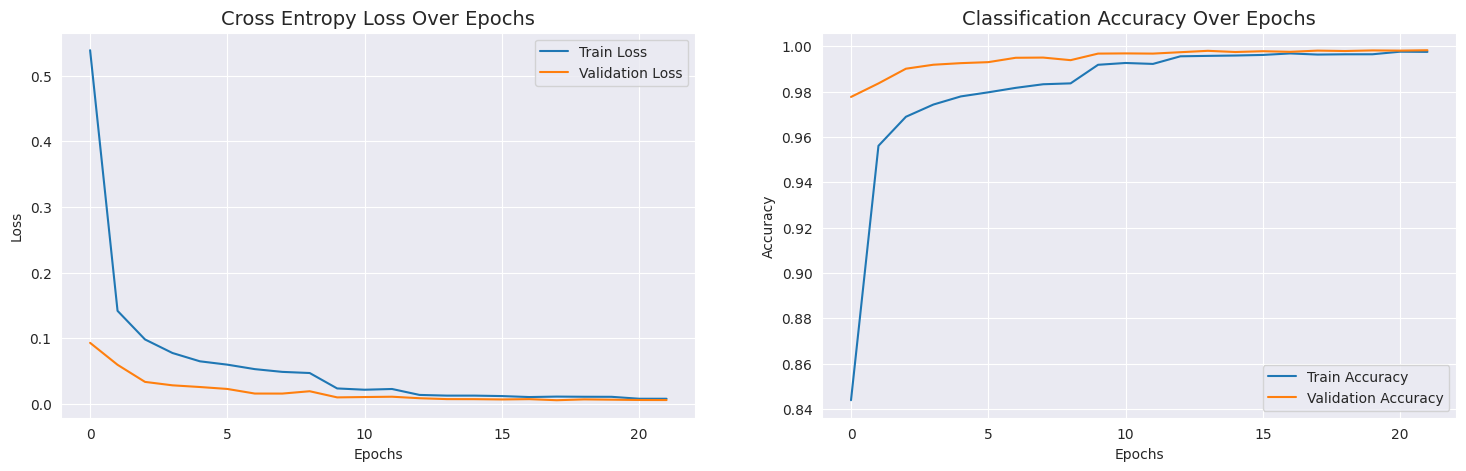


--- Generating Final Evaluation Metrics ---

Final Test Set Performance Accuracy: 99.81630444526672
Final Test Set Performance Loss: 0.006280406378209591

Correctly predicted classes: 11411
Incorrectly predicted classes: 21

Classification Report:
              precision    recall  f1-score   support

           a       1.00      1.00      1.00       452
           b       1.00      1.00      1.00       450
           c       1.00      1.00      1.00       452
           d       1.00      1.00      1.00       451
           e       1.00      1.00      1.00       451
           f       1.00      1.00      1.00       451
           g       1.00      1.00      1.00       450
           h       1.00      1.00      1.00       452
           i       1.00      1.00      1.00       451
           j       1.00      1.00      1.00       451
           k       1.00      1.00      1.00       452
           l       1.00      1.00      1.00       452
           m       1.00      1.00      1.00     

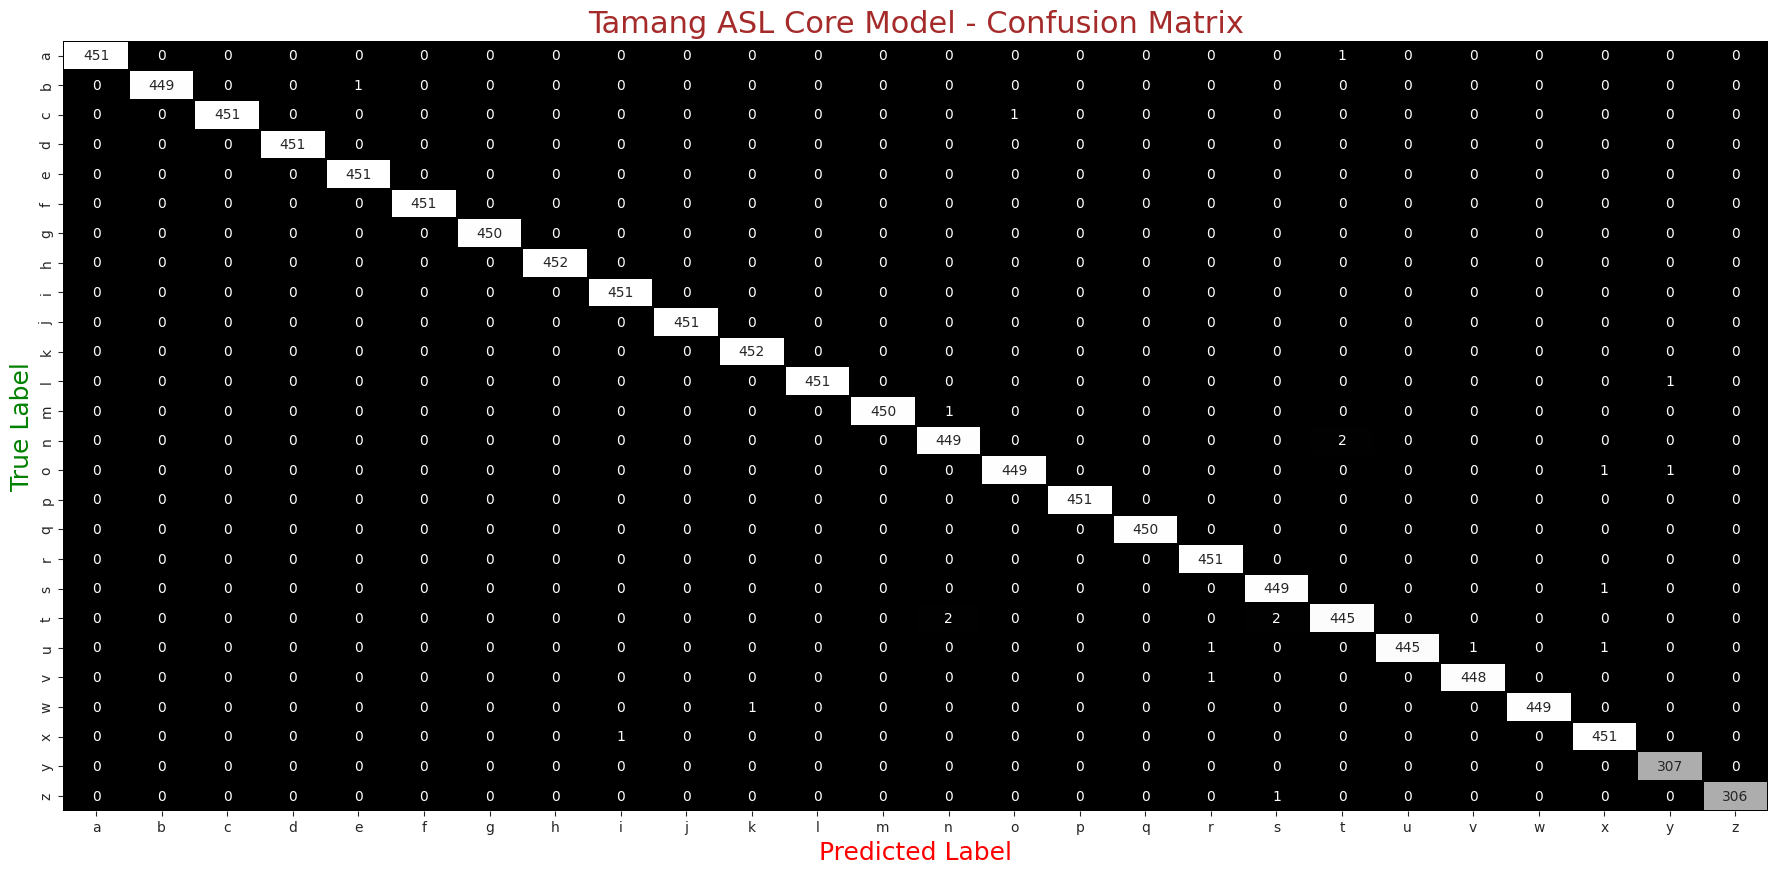

Summary: The model has correctly predicted 11411 test samples and missed 21 samples.

--- Process Complete: Model file successfully compiled and stored as 'TamangASL_model.keras' ---


In [ ]:
# TRANSFER LEARNING MODEL EXECUTION

import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from keras.models import Sequential
from keras.layers import (Dense, Conv2D, Dropout, Flatten, MaxPooling2D,
                           BatchNormalization, Input, Rescaling,
                           RandomFlip, RandomRotation, RandomZoom)
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import classification_report, confusion_matrix

# Defined target split paths
train_path = 'split_dataset/train'
val_path = 'split_dataset/val'
test_path = 'split_dataset/test'

# Count actual categories generated on disk
n_classes = len([f for f in os.listdir(train_path) if os.path.isdir(os.path.join(train_path, f))])
print(f"Dynamic Security Guard: {n_classes} target classes detected on disk.")

# Build dictionary category mapping dynamically based on folder names (a-z : 0-25)
sorted_classes = sorted([f for f in os.listdir(train_path) if os.path.isdir(os.path.join(train_path, f))])
categories = {i: sorted_classes[i] for i in range(len(sorted_classes))}
print(f"Class Mapping Configured: {list(categories.values())}")

# Hyperparameters
batch = 64
image_size = 200
img_channel = 3

AUTOTUNE = tf.data.AUTOTUNE

#
train_data = tf.keras.utils.image_dataset_from_directory(
    directory=train_path,
    label_mode='categorical',
    batch_size=batch,
    image_size=(image_size, image_size),
    shuffle=True
)

val_data = tf.keras.utils.image_dataset_from_directory(
    directory=val_path,
    label_mode='categorical',
    batch_size=batch,
    image_size=(image_size, image_size),
    shuffle=False
)

test_data = tf.keras.utils.image_dataset_from_directory(
    directory=test_path,
    label_mode='categorical',
    batch_size=batch,
    image_size=(image_size, image_size),
    shuffle=False
)

#
train_data = train_data.prefetch(buffer_size=AUTOTUNE)
val_data   = val_data.prefetch(buffer_size=AUTOTUNE)
test_data  = test_data.prefetch(buffer_size=AUTOTUNE)

from keras.applications import MobileNetV2
from keras.layers import Input, Rescaling, GlobalAveragePooling2D, Dense, Dropout
from keras.models import Sequential

def build_model():
    # MobileNetV2 as base model for Transfer Learning
    base_model = MobileNetV2(input_shape=(200, 200, 3), include_top=False, weights='imagenet')

    # Freeze the base_model so we only train the head, makes training extremely fast.
    base_model.trainable = False

    m = Sequential([
        Input(shape=(200, 200, 3)),
        Rescaling(1./127.5, offset=-1),
        base_model,
        GlobalAveragePooling2D(),
        Dense(128, activation="relu"),
        Dropout(0.3),
        Dense(26, activation="softmax"),
    ], name="TamangASL_MobileNet")

    return m

# Initialize the model
model = build_model()
model.summary()

# Optimization Settings & Callbacks
early_stoping = EarlyStopping(
    monitor='val_loss',
    min_delta=0.001,
    patience=4,  # Lowered from 5 to protect runtime limitations on larger data
    restore_best_weights=True,
    verbose=1
)

# Monitor 'val_loss' for LR reduction. Added min_lr to prevent LR decaying to zero.
reduce_learning_rate = ReduceLROnPlateau(
    monitor='val_loss',
    patience=2,
    factor=0.5,
    min_lr=1e-6,
    verbose=1
)

# Saves model into a keras file whenever "val_accuracy" improves
checkpoint = ModelCheckpoint(
    filepath="best_TamangASL.keras",
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1,
)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

# Fit Execution (Training Process)
asl_class = model.fit(
    train_data,
    validation_data=val_data,
    epochs=30,
    callbacks=[early_stoping, reduce_learning_rate, checkpoint],
    verbose=1
)

# TRANSFER LEARNING MODEL RESULTS & GRAPHS

# Training Trends Metrics Plots
error = pd.DataFrame(asl_class.history)

plt.figure(figsize=(18, 5))
sns.set_style('darkgrid')

# Loss vs Epochs
plt.subplot(121)
plt.title('Cross Entropy Loss Over Epochs', fontsize=14)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.plot(error['loss'], label='Train Loss')
plt.plot(error['val_loss'], label='Validation Loss')
plt.legend()

# Accuracy vs Epochs
plt.subplot(122)
plt.title('Classification Accuracy Over Epochs', fontsize=14)
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.plot(error['accuracy'], label='Train Accuracy')
plt.plot(error['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.show()

# Final Inference and Evaluation on Test Dataset Partition
print("\n--- Generating Final Evaluation Metrics ---")
result = model.predict(test_data, verbose=0)
y_pred = np.argmax(result, axis=1)

# Unwrap target classes out of the tf.data dataset batches structure
y_true = np.concatenate([y for x, y in test_data], axis=0)
y_true = np.argmax(y_true, axis=1)

# Overall model calculation
loss, acc = model.evaluate(test_data, verbose=0)
print('\nFinal Test Set Performance Accuracy:', acc * 100)
print('Final Test Set Performance Loss:', loss)

correct = np.nonzero(y_pred == y_true)[0]
incorrect = np.nonzero(y_pred != y_true)[0]

print(f"\nCorrectly predicted classes: {correct.shape[0]}")
print(f"Incorrectly predicted classes: {incorrect.shape[0]}")

# Generate per-class precision, recall, and f1-scores
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=list(categories.values())))

# Confusion Matrix Plotting
sns.set_style('ticks')
confusion_mtx = confusion_matrix(y_true, y_pred)

f, ax = plt.subplots(figsize=(22, 10))
sns.heatmap(
    confusion_mtx, annot=True, linewidths=0.1, cmap="gist_yarg_r",
    linecolor="black", fmt='.0f', ax=ax, cbar=False,
    xticklabels=list(categories.values()), yticklabels=list(categories.values())
)

plt.xlabel("Predicted Label", fontdict={'color':'red','size':18})
plt.ylabel("True Label", fontdict={'color':'green','size':18})
plt.title("Tamang ASL Core Model - Confusion Matrix", fontdict={'color':'brown','size':22})
plt.show()

print(f"Summary: The model has correctly predicted {correct.shape[0]} test samples and missed {incorrect.shape[0]} samples.")

# Save model
model.save('TamangASL_model.keras')
print("\n--- Process Complete: Model file successfully compiled and stored as 'TamangASL_model.keras' ---")


In [ ]:

# Load your freshly trained Keras model
model = tf.keras.models.load_model('TamangASL_model.keras')

# Convert the model to TensorFlow Lite
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

# Save the .tflite file
with open('TamangASL_model.tflite', 'wb') as f:
    f.write(tflite_model)

print("TFLite conversion complete! Download TamangASL_model.tflite")

Saved artifact at '/tmp/tmpsjmh4j8e'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 200, 200, 3), dtype=tf.float32, name='input_layer_3')
Output Type:
  TensorSpec(shape=(None, 26), dtype=tf.float32, name=None)
Captures:
  137527490051920: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137527490050576: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137526932951824: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137527490046160: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137527490045968: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137526932948560: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137526932949136: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137526932953168: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137526932950096: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137526932948368: TensorSpec(shape=(), dtype=tf.resource, name=None)
  137526932955

Fetching 16 random preprocessed images from 'master_asl_dataset'...


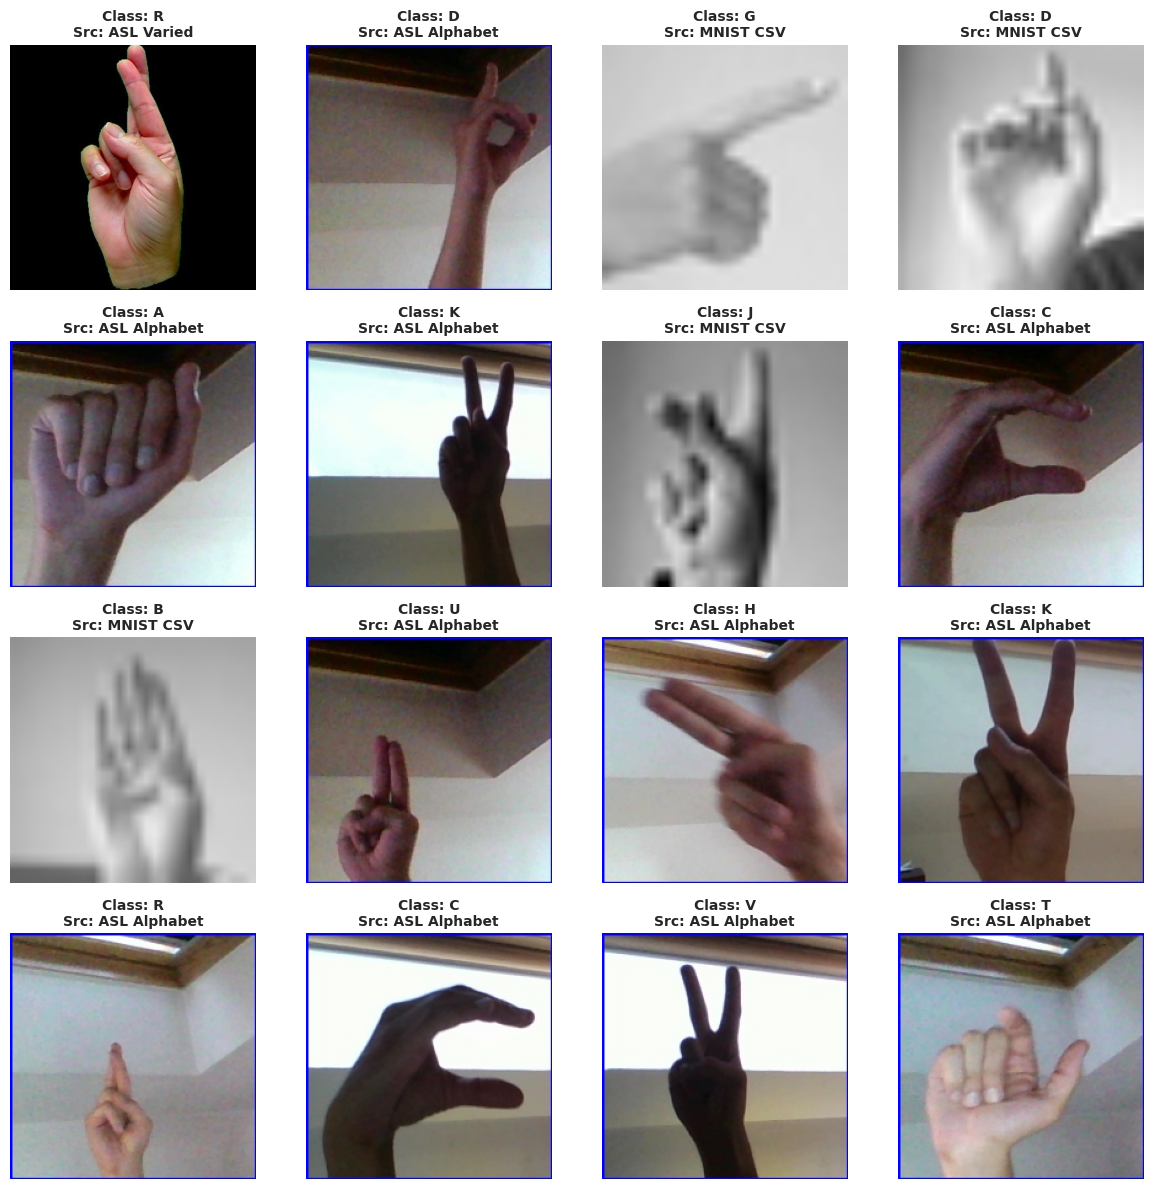

In [ ]:
# ==========================================
# EXTRA CELL: VISUALIZE PREPROCESSED SAMPLES
# ==========================================

import os
import random
import cv2
import matplotlib.pyplot as plt

UNIFIED_DIR = "master_asl_dataset"

# 1. Gather all available class folders (e.g., 'a', 'b', '1', '2')
available_classes = sorted([f for f in os.listdir(UNIFIED_DIR) if os.path.isdir(os.path.join(UNIFIED_DIR, f))])

# 2. Set up a grid of 4 rows and 4 columns to display 16 random samples
fig, axes = plt.subplots(4, 4, figsize=(12, 12))
axes = axes.ravel()

print("Fetching 16 random preprocessed images from 'master_asl_dataset'...")

for i in range(16):
    # Pick a random class folder
    random_class = random.choice(available_classes)
    class_path = os.path.join(UNIFIED_DIR, random_class)

    # Pick a random image file inside that folder
    all_images = os.listdir(class_path)
    random_img_name = random.choice(all_images)
    img_path = os.path.join(class_path, random_img_name)

    # Read the image using OpenCV
    img = cv2.imread(img_path)
    # Convert BGR (OpenCV default) to RGB (Matplotlib default)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Identify the dataset origin by looking at the file prefix we added
    if random_img_name.startswith("mnist_"):
        origin = "MNIST CSV"
    elif random_img_name.startswith("alph_"):
        origin = "ASL Alphabet"
    else:
        origin = "ASL Varied"

    # Render the image onto the grid subplot
    axes[i].imshow(img_rgb)
    axes[i].set_title(f"Class: {random_class.upper()}\nSrc: {origin}", fontsize=10, fontweight='bold')
    axes[i].axis('off') # Hide pixel coordinate axes for a cleaner look

plt.tight_layout()
plt.show()